<a href="https://colab.research.google.com/github/priyanga2004113-coder/Public_Transport_Delay_Analysis/blob/main/DA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Public Transport Delay Analysis
https://www.kaggle.com/code/sumedh1507/transport-delays-analysis-and-prediction/input

In [ ]:
#import library
import pandas as pd

#load the dataset
df = pd.read_csv("public_transport_delays.csv")

#display the shape of the dataset
print("Shape:", df.shape)

#display column information
print("\nColumn Information:")
df.info()




Shape: (2000, 24)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64

In [ ]:
#check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64


In [ ]:
#check for duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())



Duplicate Rows:
0


In [ ]:
#check unique values in each column
print("\nUnique Values:")
print(df.nunique())


Unique Values:
trip_id                       2000
date                            22
time                            96
transport_type                   4
route_id                        20
origin_station                  50
destination_station             50
scheduled_departure            474
scheduled_arrival             1068
actual_departure_delay_min      22
actual_arrival_delay_min        33
weather_condition                6
temperature_C                  397
humidity_percent                70
wind_speed_kmh                  60
precipitation_mm               201
event_type                       5
event_attendance_est             5
traffic_congestion_index       100
holiday                          2
peak_hour                        2
weekday                          7
season                           4
delayed                          2
dtype: int64


In [ ]:
#check unique values and their frequencies in the event_type column
print("Event Type Values:")
print(df["event_type"].value_counts(dropna=False))

#Display sample values from the date column
print("\nDate Sample:")
print(df["date"].head())

#Display sample values from the time column
print("\nTime Sample:")
print(df["time"].head())

Event Type Values:
event_type
NaN         1173
Festival     221
Sports       212
Concert      203
Parade       105
Protest       86
Name: count, dtype: int64

Date Sample:
0    2023-01-01
1    2023-01-01
2    2023-01-01
3    2023-01-01
4    2023-01-01
Name: date, dtype: object

Time Sample:
0    05:00:00
1    05:15:00
2    05:30:00
3    05:45:00
4    06:00:00
Name: time, dtype: object


In [ ]:
# 1. Handle missing event_type
df["event_type"] = df["event_type"].fillna("No Event")

# 2. Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# 3. Extract hour from time
df["hour"] = pd.to_datetime(df["time"], format="%H:%M:%S").dt.hour

# 4. Check the changes
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nEvent types:")
print(df["event_type"].value_counts())

print("\nDate datatype:", df["date"].dtype)

print("\nHour values:")
print(df["hour"].unique())

Missing values after cleaning:
trip_id                       0
date                          0
time                          0
transport_type                0
route_id                      0
origin_station                0
destination_station           0
scheduled_departure           0
scheduled_arrival             0
actual_departure_delay_min    0
actual_arrival_delay_min      0
weather_condition             0
temperature_C                 0
humidity_percent              0
wind_speed_kmh                0
precipitation_mm              0
event_type                    0
event_attendance_est          0
traffic_congestion_index      0
holiday                       0
peak_hour                     0
weekday                       0
season                        0
delayed                       0
hour                          0
dtype: int64

Event types:
event_type
No Event    1173
Festival     221
Sports       212
Concert      203
Parade       105
Protest       86
Name: count, dtype: int64

Da

In [ ]:
#calculate the average arrival delay
avg_delay = df["actual_arrival_delay_min"].mean()

print("Average Arrival Delay:", round(avg_delay, 2), "minutes")

Average Arrival Delay: 13.32 minutes


In [ ]:
#calculate the percentage of on - time trips
on_time_percentage = (df["delayed"] == 0).mean() * 100

print("On-Time Percentage:", round(on_time_percentage, 2), "%")

On-Time Percentage: 25.05 %


In [ ]:
#calculate the percentage of delayed trips
delayed_percentage = (df["delayed"] == 1).mean() * 100

print("Delayed Percentage:", round(delayed_percentage, 2), "%")

Delayed Percentage: 74.95 %


In [ ]:
print("Average Arrival Delay:",
      round(df["actual_arrival_delay_min"].mean(), 2), "minutes")

print("On-Time Percentage:",
      round((df["delayed"] == 0).mean() * 100, 2), "%")

print("Delayed Percentage:",
      round((df["delayed"] == 1).mean() * 100, 2), "%")

Average Arrival Delay: 13.32 minutes
On-Time Percentage: 25.05 %
Delayed Percentage: 74.95 %


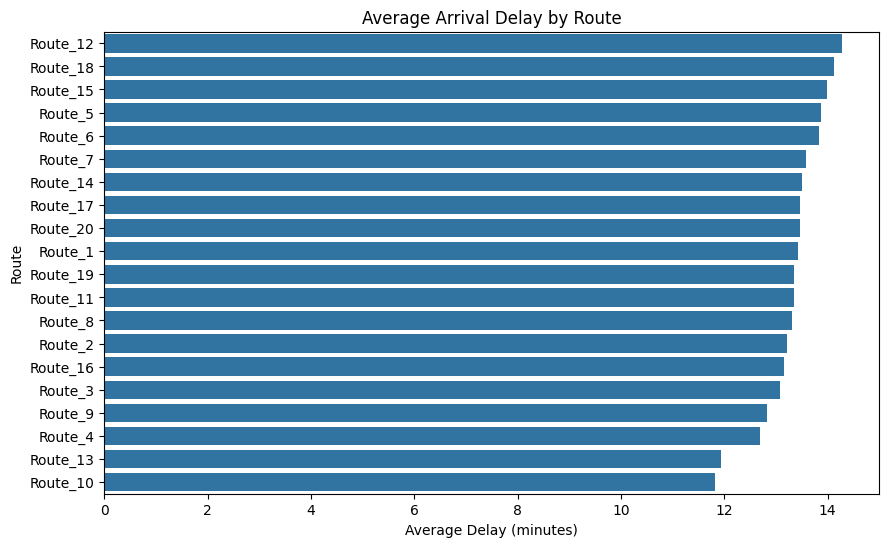

In [ ]:
#Average delay by route

import matplotlib.pyplot as plt
import seaborn as sns

route_delay = (
    df.groupby("route_id")["actual_arrival_delay_min"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=route_delay.values,
    y=route_delay.index
)

plt.title("Average Arrival Delay by Route")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Route")

plt.show()

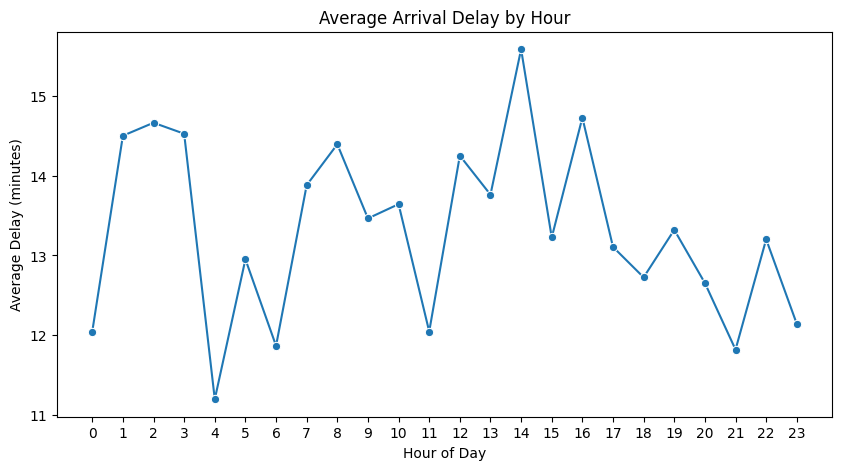

In [ ]:
#Average arrival delay by hour

hour_delay = (
    df.groupby("hour")["actual_arrival_delay_min"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=hour_delay.index,
    y=hour_delay.values,
    marker="o"
)

plt.title("Average Arrival Delay by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (minutes)")
plt.xticks(range(0, 24))

plt.show()

weekday
0    288
1    288
2    288
3    288
4    288
5    288
6    272
Name: count, dtype: int64
day_type
Weekday    1440
Weekend     560
Name: count, dtype: int64
day_type
Weekday    13.271528
Weekend    13.437500
Name: actual_arrival_delay_min, dtype: float64


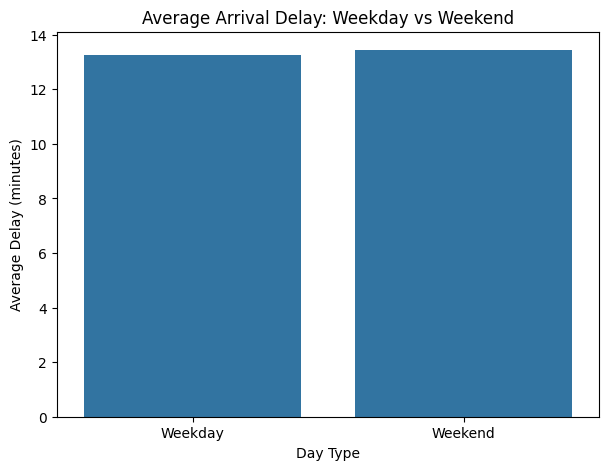

In [ ]:
#Average arrival delay for weekdays vs weekend

print(df["weekday"].value_counts().sort_index())
df["day_type"] = df["weekday"].apply(
    lambda x: "Weekend" if x in [0, 6] else "Weekday"
)

print(df["day_type"].value_counts())
day_delay = (
    df.groupby("day_type")["actual_arrival_delay_min"]
      .mean()
)

print(day_delay)
plt.figure(figsize=(7, 5))

sns.barplot(
    x=day_delay.index,
    y=day_delay.values
)

plt.title("Average Arrival Delay: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Delay (minutes)")

plt.show()

count    2000.000000
mean       50.244000
std        29.225751
min         0.000000
25%        25.000000
50%        50.000000
75%        76.000000
max        99.000000
Name: traffic_congestion_index, dtype: float64
traffic_level
Low          13.336576
Medium       13.387097
High         13.619870
Very High    12.969639
Name: actual_arrival_delay_min, dtype: float64


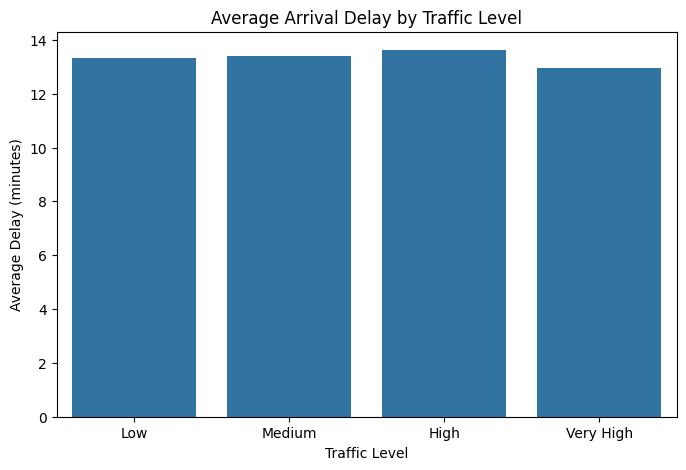

In [ ]:
#average arrival delay by traffic level

print(df["traffic_congestion_index"].describe())
df["traffic_level"] = pd.cut(
    df["traffic_congestion_index"],
    bins=[0, 25, 50, 75, 100],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)
traffic_delay = (
    df.groupby("traffic_level", observed=False)["actual_arrival_delay_min"]
      .mean()
)

print(traffic_delay)
plt.figure(figsize=(8, 5))

sns.barplot(
    x=traffic_delay.index,
    y=traffic_delay.values
)

plt.title("Average Arrival Delay by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delay (minutes)")

plt.show()

weather_condition
Rain      13.623053
Snow      13.533528
Clear     13.501458
Storm     13.287834
Cloudy    13.073846
Fog       12.879154
Name: actual_arrival_delay_min, dtype: float64


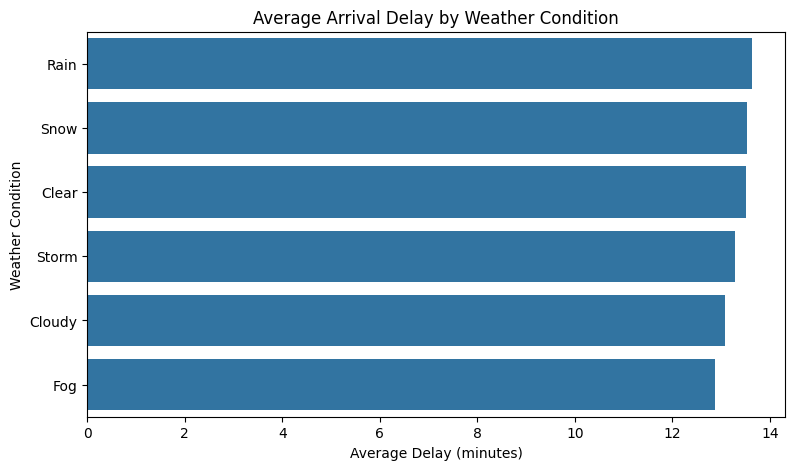

In [ ]:
#Average arrival delay by weather codition

weather_delay = (
    df.groupby("weather_condition")["actual_arrival_delay_min"]
      .mean()
      .sort_values(ascending=False)
)

print(weather_delay)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=weather_delay.values,
    y=weather_delay.index
)

plt.title("Average Arrival Delay by Weather Condition")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Weather Condition")

plt.show()

event_type
Protest     13.895349
Parade      13.619048
No Event    13.526002
Concert     12.832512
Sports      12.820755
Festival    12.769231
Name: actual_arrival_delay_min, dtype: float64


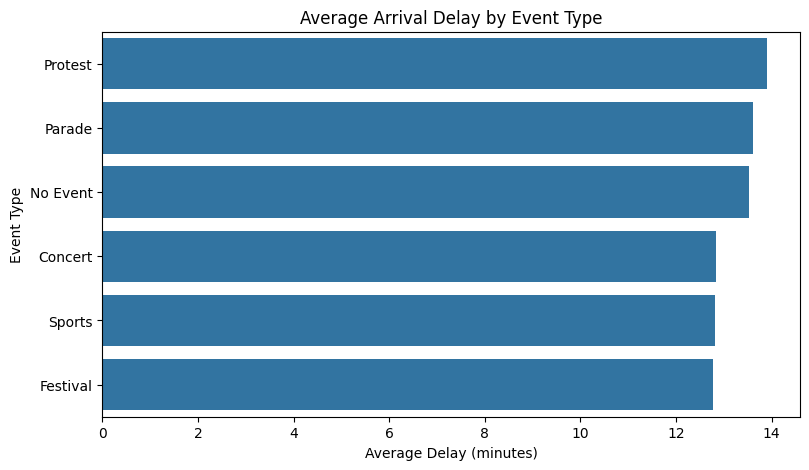

In [ ]:
#Average arrival delay by event type

event_delay = (
    df.groupby("event_type")["actual_arrival_delay_min"]
      .mean()
      .sort_values(ascending=False)
)

print(event_delay)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=event_delay.values,
    y=event_delay.index
)

plt.title("Average Arrival Delay by Event Type")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Event Type")

plt.show()

In [ ]:
#cleaned dataset
df.to_csv("transport_delays_cleaned.csv", index=False)

print("Cleaned dataset exported successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Cleaned dataset exported successfully!
Rows: 2000
Columns: 27


In [ ]:
print(df.head())
print("\nShape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sum())

  trip_id       date      time transport_type  route_id origin_station  \
0  T00000 2023-01-01  05:00:00           Tram  Route_15     Station_31   
1  T00001 2023-01-01  05:15:00          Metro  Route_12     Station_49   
2  T00002 2023-01-01  05:30:00            Bus  Route_16     Station_29   
3  T00003 2023-01-01  05:45:00           Tram  Route_19     Station_26   
4  T00004 2023-01-01  06:00:00           Tram   Route_8     Station_18   

  destination_station scheduled_departure scheduled_arrival  \
0           Station_6            05:02:00          05:55:00   
1          Station_32            05:16:00          05:55:00   
2          Station_42            05:33:00          06:17:00   
3          Station_18            05:49:00          06:08:00   
4          Station_15            06:00:00          06:35:00   

   actual_departure_delay_min  ...  event_attendance_est  \
0                          12  ...                   500   
1                          15  ...                     0